# Rural NbS Scan — Agroforestry, Haiti

**Pilot ID:** `agroforestry_hti` · **Recipe:** `schema/recipes/agroforestry/` (draft-0/1) · **Schema:** v0.3.0

This notebook runs the **full M0–M6 pipeline** end to end for Haiti + Agroforestry, and explains
what each step is doing as it runs. It is the first end-to-end pilot notebook in the repo
(Sierra Leone/agroforestry — the nominal Phase-3 priority — hasn't been scaffolded yet either),
so it also doubles as the reference template for the next NbS/country pair.

## How to read the results in this run

Every dataset this notebook needs is pulled through one function, `load_variable()`
(`src/nbs_ruralscan/data_loaders/__init__.py`), which tries **Google Earth Engine (via `xee`)
first** — the real path — and only falls back to a **synthetic placeholder raster** when GEE
isn't reachable (no credentials, no network, or that access route isn't built for this dataset
yet). Every synthetic layer is tagged `is_synthetic=True` **and** carries a
`recommended_source` string pulled straight from the dataset's own T1 metadata (its real GEE
asset id, download URL, and citation) — so wherever this run had to fake a layer, you get a
direct pointer to what to wire up next, not a guess.

**On the machine you'll actually run this on:**
```bash
pip install earthengine-api xee
earthengine authenticate      # once — opens a browser OAuth flow
```
then before running the cells below:
```python
import ee
ee.Initialize(project="your-gcp-project")
```
With that done, every `gee_asset`-type variable in this recipe (most of them) pulls real data
automatically — nothing else in this notebook needs to change.

In [3]:
!pip install xarray rioxarray earthengine-api xee

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 4.0 MB/s  0:00:00
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ----------- ---------------------------- 1.8/6.4 MB 10.0 MB/s eta 0:00:01
   ----------------------------------- ---- 5.8/6.4 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 6.4/6.4 MB 11.6 MB/s  0:00:00

   ---------- ----------------------------- 2/8 [tblib]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------------- 5/8 [bokeh]
   ------------------------- -------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path('D:/OneDrive - CGIAR/Desktop/codigos_dengue/nbs_ruralscan')

# Esta línea es la que le avisa a Python dónde buscar el paquete.
# No mueve nada de carpeta -- solo agrega esa ruta a la lista de lugares donde busca imports.
src_path = str(REPO_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray 

import ee
import xee 


from nbs_ruralscan.runtime.schema_loader import load_recipe, aoi_contexts, recipe_readiness
from nbs_ruralscan.runtime.suitability import run_m1
from nbs_ruralscan.runtime.climate_risk import run_m2
from nbs_ruralscan.runtime.characterisation import run_m3
from nbs_ruralscan.runtime.hotspots import run_m4
from nbs_ruralscan.runtime.scorecard import run_m5
from nbs_ruralscan.runtime.handoff import handoff_card

import nbs_ruralscan
print("nbs_ruralscan cargado desde:", nbs_ruralscan.__file__)

SCHEMA_ROOT = REPO_ROOT / "schema"
print("SCHEMA_ROOT existe:", SCHEMA_ROOT.exists())


nbs_ruralscan cargado desde: D:\OneDrive - CGIAR\Desktop\codigos_dengue\nbs_ruralscan\src\nbs_ruralscan\__init__.py
SCHEMA_ROOT existe: True


In [2]:
ee.Authenticate()
ee.Initialize(project="ee-diegoagudelo30-2")

## 2. Configuration

In [3]:
NBS_ID = "agroforestry"
ADMIN_COUNTRY = "HTI"           # added to T7 this session — must exist as admin_country
RESOLUTION_M = 5000              # coarse first pass; tighten once real GEE pulls are wired in
SCENARIO = "baseline"

# Haiti bbox (minx, miny, maxx, maxy), EPSG:4326 — placeholder until the real GADM polygon for
# HTI is pulled via T7.dataset_id (gadm_v41_admin). Good enough to size the analysis grid.
AOI_BBOX = (-74.5, 18.0, -71.6, 20.1)

recipe = load_recipe(SCHEMA_ROOT, NBS_ID)
contexts = aoi_contexts(recipe.t7, ADMIN_COUNTRY)
readiness = recipe_readiness(recipe)
readiness


{'nbs_id': 'agroforestry',
 'n_suitability_variables': 19,
 'n_with_literature_evidence': 13,
 'n_placeholder': 6,
 'n_priority_variables_root': 12}

In [4]:
recipe.t4

,mapping_id,nbs_id,dataset_id,suitability_dimension,relationship_type,relationship_params,uncertainty_pct,context_overrides,is_scenario_candidate,scenario_label,...,future_dataset_ids,weight_default,weight_adjustable,justification,variable,suitability_family_id,evidence_ids,n_sources,corpus_n,paper_support_pct
0,agro_slope_global,agroforestry,srtm_dem_90m,biophysical_constraint,trapezoidal,"{""abs_min"":0.0,""opt_low"":0.0,""opt_high"":5.0,""a...",60.0,"[{""context_type"":""aez"",""context_id"":""humid_tro...",False,NaN,...,NaN,0.15,True,Reconciled from 16 evidence unit(s) (weighted ...,slope,agroforestry__planted_silvoarable,NaN,16,36,46.3
1,agro_annual_precip_global,agroforestry,worldclim_v2_bioclim,biophysical_constraint,trapezoidal,"{""abs_min"":770.0,""opt_low"":800.0,""opt_high"":10...",60.0,"[{""context_type"":""aez"",""context_id"":""humid_tro...",False,NaN,...,"{""ssp245"":""chelsa_bioclim_ssp245_2050""}",0.15,True,Reconciled from 10 evidence unit(s) (weighted ...,annual_precipitation,agroforestry__planted_silvoarable,NaN,14,36,41.6
2,agro_mean_annual_temp_global,agroforestry,worldclim_v2_bioclim,biophysical_constraint,trapezoidal,"{""abs_min"":5.0,""opt_low"":20.0,""opt_high"":25.5,...",60.0,"[{""context_type"":""aez"",""context_id"":""sub_humid...",False,NaN,...,"{""ssp245"":""chelsa_bioclim_ssp245_2050""}",0.10,True,Reconciled from 6 evidence unit(s) (weighted m...,mean_annual_temperature,agroforestry__planted_silvoarable,NaN,7,36,20.0
3,agro_soil_ph_global,agroforestry,isric_soilgrids250_v2,biophysical_constraint,trapezoidal,"{""abs_min"":5.0,""opt_low"":6.5,""opt_high"":7.3,""a...",18.0,NaN,False,NaN,...,NaN,0.10,True,Reconciled from 7 evidence unit(s) (weighted m...,soil_ph,agroforestry__planted_silvoarable,NaN,9,36,25.2
4,agro_soil_organic_carbon_global,agroforestry,isric_soilgrids250_v2,biophysical_constraint,linear_increasing,"{""abs_min"":0.5,""opt_low"":0.8}",60.0,NaN,False,NaN,...,NaN,0.08,True,Reconciled from 6 evidence unit(s) (weighted m...,soil_organic_carbon,agroforestry__planted_silvoarable,NaN,7,36,19.6
5,agro_soil_drainage_global,agroforestry,hwsd_v2,biophysical_constraint,ranked_classes,"{""abs_min"":1.0,""opt_low"":3.0,""opt_high"":4.0,""a...",10.0,NaN,False,NaN,...,NaN,0.08,True,Reconciled from 3 evidence unit(s) (weighted m...,soil_drainage,agroforestry__planted_silvoarable,NaN,3,36,10.0
6,agro_land_cover_eligibility,agroforestry,esa_worldcover_2021,system_constraint,ranked_classes,"{""class_map"":{""10"":1.0,""20"":0.9,""30"":0.7,""40"":...",0.0,NaN,False,NaN,...,NaN,0.10,False,"Land cover is an eligibility filter, not a gra...",land_cover,agroforestry__planted_silvoarable,NaN,6,36,25.0
7,agro_protected_areas_exclusion,agroforestry,protected_areas_wdpa,operational_constraint,threshold,"{""threshold"":""IUCN_Cat_I_II"",""above_is_suitabl...",0.0,NaN,False,NaN,...,NaN,1.00,False,Strict nature reserves (IUCN I–II) prohibit ag...,protected_area_status,agroforestry__planted_silvoarable,NaN,3,36,13.2
8,agro_road_access_scenario,agroforestry,osm_road_network,operational_constraint,linear_decreasing,"{""abs_min"":0.0,""opt_low"":0.0,""opt_high"":3.0,""a...",60.0,NaN,True,What if roads were accessible?,...,NaN,0.08,True,Reconciled from 3 evidence unit(s) (weighted m...,distance_to_road,agroforestry__planted_silvoarable,NaN,3,36,10.0
9,agro_aridity_index_global,agroforestry,global_aridity_index_v3,biophysical_constraint,trapezoidal,"{""abs_min"":5000.0,""opt_low"":35000.0}",20.0,NaN,False,NaN,...,NaN,0.08,True,Reconciled from 1 evidence unit(s) (weighted m...,aridity_index,agroforestry__planted_silvoarable,NaN,1,36,2.8


**Reading `readiness`:** `n_with_literature_evidence` counts T4 rows with `n_sources > 0`
— the real evidence signal (`evidence_ids` itself is largely unpopulated in this draft). Rows
below that count are placeholder response functions pending Namita/MFL literature review —
carry that caveat into anything this notebook produces for a real decision.

## 3. M1 — Suitability

Runs the full M1 sub-pipeline (spec `methodology/modules/M1_suitability.md` §6.1–6.8) in one
call:

1. **Assemble** (§6.1) — pull every T4 variable's raster for the AOI.
2. **Standardise** (§6.2) — fuzzy-transform each raw raster to 0–1 per its
   `relationship_type` (trapezoidal / linear / ranked-classes / threshold — see
   `runtime/fuzzy.py`).
3. **Reduce** (§6.3) — cluster variables with |Pearson r| > 0.7, keep one representative per
   cluster (Ani's principle 1).
4. **Weight** (§6.4) — CRITIC (objective, computed from the actual data) reconciled with each
   row's literature-derived `weight_default` (subjective) at α = 0.4.
5. **Exclude** (§6.5) — any `threshold`-type row becomes a hard mask, not a graded criterion.
6. **Overlay + sensitivity + classify** (§6.6–6.8) — the shipped `mcda.py` engine.

In [4]:
m1 = run_m1(recipe.t4, recipe.t1, AOI_BBOX, resolution_m=RESOLUTION_M)

audit_df = pd.DataFrame([vars(a) for a in m1["resolution_audit"]])
print(f"{(~audit_df['is_synthetic']).sum()}/{len(audit_df)} variables pulled from a real source")
print(f"{audit_df['is_synthetic'].sum()}/{len(audit_df)} variables are synthetic placeholders this run")
audit_df


c:\Users\dagudelo\venv_ia_generativa\Lib\site-packages\xee\ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
'slope': reprojecting onto the shared grid left 846/3055 pixel(s) as NaN (source extent didn't exactly cover the target grid) -- filled with the layer's mean (102.6) so downstream weighting stays finite.
'annual_precipitation': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='worldclim_v2_bioclim' | WorldClim v2.1 Bioclimatic Variables | GEE asset: WORLDCLIM/V1/BIO | source: https://www.worldclim.org/data/worldclim21.html | cite: Fick, S.E. & Hijmans, R.J. (2017). WorldClim 2: new 1km spatial resolution climate surfaces for global land areas. International Journal of Climatology, 37(12), 4302–4315.
'annual_precipitation': reprojecting onto the shared grid left 47/3055 pixel(s) as NaN (sourc

7/19 variables pulled from a real source
12/19 variables are synthetic placeholders this run


,variable,dataset_id,native_resolution_m,analysis_resolution_m,is_synthetic,recommended_source
0,slope,srtm_dem_90m,30.0,5000,False,None
1,annual_precipitation,worldclim_v2_bioclim,1000.0,5000,True,dataset_id='worldclim_v2_bioclim' | WorldClim ...
2,mean_annual_temperature,worldclim_v2_bioclim,1000.0,5000,True,dataset_id='worldclim_v2_bioclim' | WorldClim ...
3,soil_ph,isric_soilgrids250_v2_ph,250.0,5000,False,None
4,soil_organic_carbon,isric_soilgrids250_v2_soc,250.0,5000,False,None
5,soil_drainage,hwsd_v2,1000.0,5000,True,dataset_id='hwsd_v2' | Harmonized World Soil D...
6,land_cover,esa_worldcover_2021,10.0,5000,False,None
7,protected_area_status,protected_areas_wdpa,NaN,5000,True,dataset_id='protected_areas_wdpa' | World Data...
8,distance_to_road,osm_road_network,NaN,5000,True,dataset_id='osm_road_network' | OpenStreetMap ...
9,aridity_index,global_aridity_index_v3,1000.0,5000,True,dataset_id='global_aridity_index_v3' | Global ...


In [4]:
print("Variables:", len(recipe.t4), "-> after correlation reduction:", len(m1["kept_variables"]))
print("Kept:", m1["kept_variables"])
print()
print("Cluster log (variable -> representative it was merged into, if different):")
for var, rep in m1["cluster_log"].items():
    if var != rep:
        print(f"  {var} -> {rep}")


Variables: 19 -> after correlation reduction: 19
Kept: ['slope', 'annual_precipitation', 'mean_annual_temperature', 'soil_ph', 'soil_organic_carbon', 'soil_drainage', 'land_cover', 'protected_area_status', 'distance_to_road', 'aridity_index', 'tree_canopy_cover', 'accessibility_travel_time', 'electrification_index', 'tenure_security', 'conflict_fragility_index', 'extension_governance', 'finance_credit_access', 'market_value_chain', 'labour_availability']

Cluster log (variable -> representative it was merged into, if different):


In [5]:
m1["weight_log"].round(3)

,variable,weight_default_t4,ahp_weight,critic_weight,final_weight_alpha_0.4
0,slope,0.054,0.054,0.062,0.059
1,annual_precipitation,0.054,0.054,0.064,0.060
2,mean_annual_temperature,0.036,0.036,0.059,0.050
3,soil_ph,0.036,0.036,0.063,0.052
4,soil_organic_carbon,0.029,0.029,0.033,0.031
5,soil_drainage,0.029,0.029,0.063,0.049
6,land_cover,0.036,0.036,0.000,0.014
7,protected_area_status,0.357,0.357,0.096,0.200
8,distance_to_road,0.029,0.029,0.062,0.049
9,aridity_index,0.029,0.029,0.056,0.045


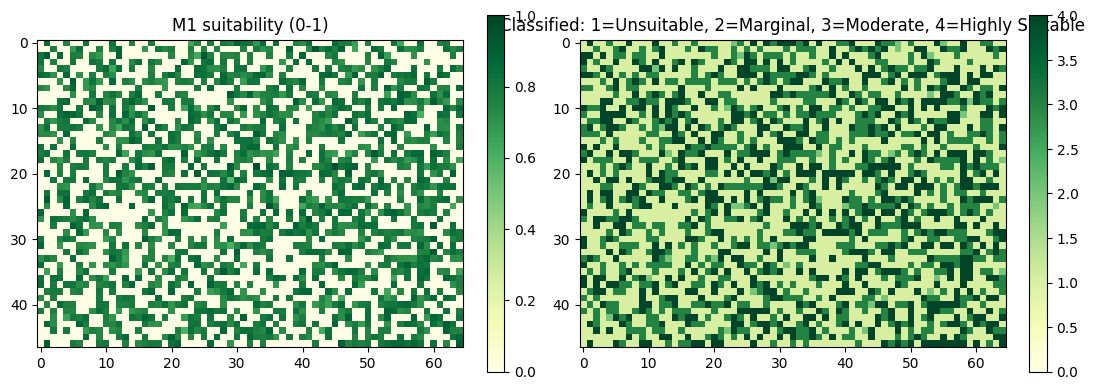

Fingerprint: {'total_cells': 3055, 'cells_by_class': {'Unsuitable': 1492, 'Marginal': 36, 'Moderate': 763, 'Highly Suitable': 764}, 'opportunity_space_share': 0.4998363338788871}
Mean sensitivity variance (+/-10% weight perturbation, n=50): 3.646228772791794e-05


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(m1["suitability"], cmap="YlGn", vmin=0, vmax=1)
axes[0].set_title("M1 suitability (0-1)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(m1["classes"], cmap="YlGn", vmin=0, vmax=4)
axes[1].set_title("Classified: " + ", ".join(f"{k}={v}" for k, v in m1["legend"].items()))
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

print("Fingerprint:", m1["fingerprint"])
print("Mean sensitivity variance (+/-10% weight perturbation, n=50):", float(m1["sensitivity"].variance.mean()))


**Caveat carried forward:** every layer above is synthetic in this environment (no GEE
credentials), so the *map pattern* is meaningless — only the *plumbing* is validated. Re-run
this notebook on a machine with `ee.Initialize()` already done and the same cells produce a
real Haiti suitability surface, unchanged.

## 4. M2 — Rural climate risk

Mode A only (`Risk = Σ w_i · Hazard_i · mean(Exposure)`) — the spec's own recommended v0
scope; Mode B (full H×E×Vulnerability) needs a methodology call on how sensitivity + adaptive
capacity combine, not guessed at here (see `runtime/climate_risk.py::compose_vulnerability`).

This is a **separate question from M1**: M1 asks where agroforestry could work biophysically;
M2 asks where the rural hazards agroforestry can plausibly mitigate are most severe.

In [7]:
m2 = run_m2(recipe.t2, recipe.t3, recipe.t1, AOI_BBOX, resolution_m=RESOLUTION_M, scenario_type=SCENARIO)

print("Hazards agroforestry mitigates for rural livelihoods (T3):", m2["hazards"])
print("Hazards with an actual T2 dataset row today:", list(m2["hazard_layers"].keys()))
missing = [h for h in m2["hazards"] if h not in m2["meta"]["hazard_weights"]]
if missing:
    print("GAP -- no T2 row yet for:", missing, "(real recipe gap, not a bug -- flag for Brayden)")
print()
print("Hazard weights used:", m2["meta"]["hazard_weights"])


'drought_spei12_baseline': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='spei_global_v26' | Global SPEI Database v2.6 | GEE asset: nan | source: https://spei.csic.es/database.html | cite: Vicente-Serrano, S.M. et al. (2010). A Multiscalar Drought Index Sensitive to Global Warming: The Standardized Precipitation Evapotranspiration Index. Journal of Climate, 23(7), 1696–1718.


'heat_stress_tmax_baseline': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='chelsa_bioclim_v21_baseline' | CHELSA Bioclimatic Variables v2.1 (Baseline) | GEE asset: nan | source: https://chelsa-climate.org/bioclim/ | cite: Karger, D.N. et al. (2017). Climatologies at high resolution for the earth's land surface areas (CHELSA). Scientific Data, 4, 170122.


'flood_exposure_baseline': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='chelsa_bioclim_v21_baseline' | CHELSA Bioclimatic Variables v2.1 (Baseline) | GEE asset: nan | source: https://chelsa-climate.org/bioclim/ | cite: Karger, D.N. et al. (2017). Climatologies at high resolution for the earth's land surface areas (CHELSA). Scientific Data, 4, 170122.


'flood_hazard_runoff_depth': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='scs_cn_runoff_composite' | HydroSHEDS Watershed Boundaries and River Network | GEE asset: WWF/HydroSHEDS/v1/Basins/hybas_12 | source: https://www.hydrosheds.org/ | cite: Lehner, B. et al. (2008). New global hydrography derived from spaceborne elevation data. Eos, Transactions AGU, 89(10), 93-94.


'agricultural_cropland_exposure': GEE pull failed (EEException: Earth Engine client library not initialized. See http://goo.gle/ee-auth.) -- falling back to synthetic. Common causes: `ee.Initialize()` not called yet, no internet path to Google from this environment, or the asset id is stale. Recommended source: dataset_id='esa_worldcover_2021' | ESA WorldCover 2021 (10m Land Cover) | GEE asset: ESA/WorldCover/v200 | source: https://esa-worldcover.org/ | cite: Zanaga, D. et al. (2022). ESA WorldCover 10m 2021 v200. Zenodo.


'population_exposure_rural': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='worldpop_population_density' | WorldPop Population Density 2020 (constrained, 100m) | GEE asset: WorldPop/GP/100m/pop | source: https://hub.worldpop.org/geodata/listing?id=75 | cite: WorldPop (2020). Global High Resolution Population Denominators Project - Funded by The Bill & Melinda Gates Foundation (OPP1134076). University of Southampton.


'rainfall_variability_exposure': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='chirps_precipitation_v2' | WorldClim v2.1 Monthly Precipitation | GEE asset: WORLDCLIM/V1/MONTHLY | source: https://www.worldclim.org/data/worldclim21.html | cite: Fick, S.E. & Hijmans, R.J. (2017). WorldClim 2: new 1km spatial resolution climate surfaces for global land areas. International Journal of Climatology, 37(12), 4302-4315.


Hazards agroforestry mitigates for rural livelihoods (T3): ['drought', 'fire', 'flood', 'heat_stress', 'waterlogging', 'wind_cyclone']
Hazards with an actual T2 dataset row today: ['drought_spei12_baseline', 'heat_stress_tmax_baseline', 'flood_exposure_baseline', 'flood_hazard_runoff_depth']
GAP -- no T2 row yet for: ['drought', 'fire', 'flood', 'heat_stress', 'waterlogging', 'wind_cyclone'] (real recipe gap, not a bug -- flag for Brayden)

Hazard weights used: {'drought_spei12_baseline': 0.348605577689243, 'heat_stress_tmax_baseline': 0.17330677290836652, 'flood_exposure_baseline': 0.1155378486055777, 'flood_hazard_runoff_depth': 0.36254980079681276}


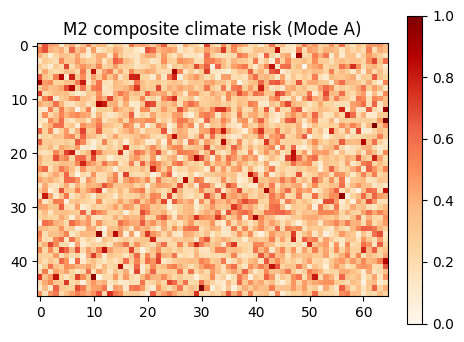

In [8]:
plt.figure(figsize=(5, 4))
plt.imshow(m2["composite_risk"], cmap="OrRd", vmin=0, vmax=1)
plt.colorbar(fraction=0.046)
plt.title("M2 composite climate risk (Mode A)")
plt.show()


## 5. M3 — Opportunity space characterisation

Within M1's opportunity-space mask (top 2 suitability classes), describes who lives there and
what development problems are most present — poverty, biodiversity, water stress, etc. (T5
`mcda_role == 'priority'` rows). Descriptor rows (population, farm size, accessibility,
production value) give context but are never weighted into MCDA.

In [9]:
opp_mask = m1["classes"] >= 3  # top 2 quartile classes = the opportunity space

m3 = run_m3(recipe.t5, recipe.t1, AOI_BBOX, resolution_m=RESOLUTION_M, opp_mask=opp_mask)

print("Priority variables characterised:", list(m3["standardised_priorities"].keys()))
print()
print("Fingerprint (context, not weighted):")
for k, v in m3["fingerprint"].items():
    print(f"  {k}: {v}")


2 priority variable(s) have no dataset_id in T5 yet -- skipped: ['soil_erosion_risk', 'production_gap']. These need a dataset assigned before M3/M4 can use them.


'drought_hazard': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='spei_global_v26' | Global SPEI Database v2.6 | GEE asset: nan | source: https://spei.csic.es/database.html | cite: Vicente-Serrano, S.M. et al. (2010). A Multiscalar Drought Index Sensitive to Global Warming: The Standardized Precipitation Evapotranspiration Index. Journal of Climate, 23(7), 1696–1718.


'flood_hazard': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='jrc_global_flood_hazard' | JRC Global Flood Hazard Maps (Dottori et al. 2016) | GEE asset: nan | source: https://data.jrc.ec.europa.eu/dataset/jrc-floods-floodmapgl_rp50y-tif | cite: Dottori, F., Salamon, P., Bianchi, A., Alfieri, L., Hirpa, F. A., & Feyen, L. (2016). Development and evaluation of a framework for global flood hazard mapping. Advances in Water Resources, 94, 87-102.


'heat_stress_hazard': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='chelsa_bioclim_v21_baseline' | CHELSA Bioclimatic Variables v2.1 (Baseline) | GEE asset: nan | source: https://chelsa-climate.org/bioclim/ | cite: Karger, D.N. et al. (2017). Climatologies at high resolution for the earth's land surface areas (CHELSA). Scientific Data, 4, 170122.


'carbon_sequestration_potential': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='fao_gsoc_map' | FAO Global Soil Organic Carbon Map (GSOCmap) v1.6.1 | GEE asset: nan | source: https://www.fao.org/soils-portal/soil-survey/soil-maps-and-databases/global-soil-organic-carbon-map-gsocmap/en/ | cite: FAO & ITPS (2018). Global Soil Organic Carbon Map (GSOCmap) v1.6.1. Technical Report. FAO, Rome.


...

'rural_population': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='worldpop_population_density' | WorldPop Population Density 2020 (constrained, 100m) | GEE asset: WorldPop/GP/100m/pop | source: https://hub.worldpop.org/geodata/listing?id=75 | cite: WorldPop (2020). Global High Resolution Population Denominators Project - Funded by The Bill & Melinda Gates Foundation (OPP1134076). University of Southampton.


'accessibility_travel_time': GEE pull failed (EEException: Earth Engine client library not initialized. See http://goo.gle/ee-auth.) -- falling back to synthetic. Common causes: `ee.Initialize()` not called yet, no internet path to Google from this environment, or the asset id is stale. Recommended source: dataset_id='nelson_accessibility_2015' | Global accessibility to cities — Weiss et al. (Nelson) 2018, 2015 baseline | GEE asset: Oxford/MAP/accessibility_to_cities_2015_v1_0 | source: https://malariaatlas.org/explorer/ | cite: Weiss, D. J., et al. (2018). A global map of travel time to cities to assess inequalities in accessibility in 2015. Nature, 553, 333-336.


'farm_size': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='lesiv_smallholder_farm_size' | Lesiv et al. Global field-size / smallholder share | GEE asset: nan | source: https://pure.iiasa.ac.at/15526 | cite: Lesiv, M., Bayas, J. C. L., See, L., Duerauer, M., Dahlia, D., Durando, N., et al. (2019). Estimating the global distribution of field size using crowdsourcing. Global Change Biology, 25, 174-186.


'agricultural_production_value': no loader implemented yet for access_type='direct_download'. Recommended source to explore next: dataset_id='mapspam_v2' | MapSPAM 2017 v2.0 — global crop production value | GEE asset: nan | source: https://www.mapspam.info/ | cite: International Food Policy Research Institute (IFPRI) (2024). Global Spatially-Disaggregated Crop Production Statistics Data for 2017 Version 2.0. Harvard Dataverse.


Priority variables characterised: ['drought_hazard', 'flood_hazard', 'heat_stress_hazard', 'carbon_sequestration_potential', 'biodiversity_priority', 'water_stress', 'rural_poverty', 'agricultural_dependency', 'gender_inequity', 'iplc_lands']

Fingerprint (context, not weighted):
  total_cells: 1527
  opportunity_space_share: 0.4998363338788871
  rural_population_mean_in_opp_space: 0.500639514559858
  accessibility_travel_time_mean_in_opp_space: 0.4851490342753294
  farm_size_mean_in_opp_space: 0.5094636742854446
  agricultural_production_value_mean_in_opp_space: 0.49642118917526135


In [10]:
m3["problem_distribution"].round(2)

,variable,Low,Moderate,High,Very High
0,drought_hazard,0.25,0.23,0.27,0.25
1,flood_hazard,0.23,0.24,0.25,0.27
2,heat_stress_hazard,0.25,0.24,0.25,0.25
3,carbon_sequestration_potential,0.26,0.24,0.26,0.25
4,biodiversity_priority,0.25,0.24,0.25,0.26
5,water_stress,0.25,0.24,0.27,0.24
6,rural_poverty,0.24,0.25,0.24,0.27
7,agricultural_dependency,0.23,0.25,0.27,0.25
8,gender_inequity,0.23,0.25,0.26,0.25
9,iplc_lands,0.26,0.23,0.25,0.26


## 6. M4 — Priority hotspots (MCDA)

Combines M3's standardised priority layers using **TTL-supplied conceptual weights**
(`-` / `L` / `M` / `H` per priority) into a single hotspot score — reusing `mcda.py` directly,
per the spec's explicit "reuse, don't duplicate" instruction.

The weights below are a placeholder ("everything = Medium") — replace `TTL_WEIGHTS` with the
actual priority levels a TTL would set for this Haiti pilot (e.g. `rural_poverty: "H"` if
poverty reduction is the driving objective) before treating this as a real prioritisation.

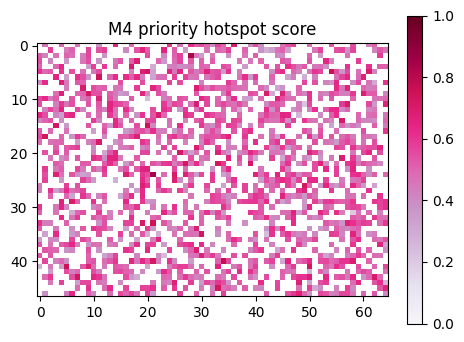

,mean_hotspot_score,share_very_high,top_drivers
0,0.506269,0.001309,"[(flood_hazard, 0.025876291812268006), (agricu..."


In [11]:
TTL_WEIGHTS = {v: "M" for v in m3["standardised_priorities"]}  # placeholder — edit per real TTL input

m4 = run_m4(
    m3["standardised_priorities"],
    TTL_WEIGHTS,
    opp_mask,
    m1["suitability"],
    project_risk=None,  # M2b (project/asset risk) not implemented yet — see pipeline status
)

plt.figure(figsize=(5, 4))
plt.imshow(m4["hotspot"], cmap="PuRd", vmin=0, vmax=1)
plt.colorbar(fraction=0.046)
plt.title("M4 priority hotspot score")
plt.show()

m4["ranked_units"]


## 7. M5 — NbS scorecard

Qualitative only — Likert effects (T6) paired with how present each problem is in the
opportunity space (M3's `problem_distribution`), plus an indicative economic archetype.
**Not a cost-benefit analysis** — that's downstream (M6).

In [12]:
m5 = run_m5(recipe.t6, recipe.t5, recipe.t2, m3["problem_distribution"])

print("Full scorecard:")
display(m5["scorecard"][["variable_id", "effect_direction", "effect_confidence"]])

print()
print("Cautions (negative effects to flag explicitly, not bury in the table):")
display(m5["cautions"][["variable_id", "effect_direction", "effect_mechanism"]] if len(m5["cautions"]) else "None")

print()
print("Economic archetype (scoping-grade, not a CBA):")
for k, v in m5["economic_profile_scoping_grade"].items():
    print(f"  {k}: {v}")


Full scorecard:


,variable_id,effect_direction,effect_confidence
0,rural_poverty,moderate_positive,medium
1,carbon_sequestration_potential,strong_positive,high
2,production_gap,moderate_positive,medium
3,biodiversity_priority,strong_positive,medium
4,soil_erosion_risk,strong_positive,high
5,drought,moderate_positive,high
6,establishment_cost,moderate_negative,medium
7,accessibility_travel_time,slight_positive,medium



Cautions (negative effects to flag explicitly, not bury in the table):


,variable_id,effect_direction,effect_mechanism
6,establishment_cost,moderate_negative,Agroforestry establishment requires upfront in...



Economic archetype (scoping-grade, not a CBA):
  income_potential: {"low":50,"high":500,"unit":"usd_per_ha_yr","source_note":"Wide range reflects variation from subsistence parkland systems (~$50/ha/yr in additional income) to intensively managed silvoarable or carbon-credited systems (~$500/ha/yr). Marinis et al. (2022) report NPV of CAD $1.186 billion at landscape scale. Palma et al. (2007) demonstrate positive iNPV for European silvoarable systems."}
  carbon_revenue: {"low":20,"high":200,"unit":"usd_per_ha_yr","source_note":"Based on sequestration rates of 1–10 t CO₂/ha/yr × carbon price of $10–30/t. Kiziridis et al. (2026) map silvopastoral carbon sequestration potential for climate policy. Mendonça et al. (2023) use SOC sequestration potential as the primary prioritisation criterion."}
  cost_reduction: {"low":20,"high":150,"unit":"usd_per_ha_yr","source_note":"Avoided fertiliser costs and soil remediation costs. Castle et al. (2025) use soil erosion reduction (GloSEM model) as 

## 8. M6 — Implementation hand-off

Content, not computation: the narrative bridge from scoping to feasibility. Points at the
valuation toolbox (InVEST, RUSLE, IPCC Tier 1-3 carbon accounting, CBA — Stocktake Table 6) as
next steps; never computes them here.

In [13]:
card = handoff_card(
    "agroforestry",
    m4["ranked_units"],
    m5["economic_profile_scoping_grade"],
    iplc_overlap=False,  # TODO: real check once T7 carries Haiti IPLC-lands geometry
)

print("Stage:", card["current_stage"], "->", " -> ".join(card["stage_pathway"][1:]))
print()
print("Recommended next steps:")
for step in card["recommended_next_steps"]:
    print(" -", step)
print()
print("Feasibility-stage methods to reach for next (never computed here):")
for k, v in card["feasibility_methods"].items():
    print(f"  {k}: {v}")


Stage: Scoping (this tool) -> Pre-feasibility -> Feasibility & design -> Implementation

Recommended next steps:
 - Validate priority units identified by M4 in the field.
 - Stakeholder and tenure mapping (especially where iplc_lands overlap is flagged).
 - Full cost-benefit and financing scan.
 - Safeguards / ESG screening.

Feasibility-stage methods to reach for next (never computed here):
  nature_based: ['InVEST', 'RUSLE (soil erosion)', 'IPCC Tier 1-3 carbon accounting']
  integrated: ['Cost-benefit analysis (CBA)', 'Multi-criteria decision analysis (MCDA)']


## 9. Recommended sources — every dataset this run had to fake

In [14]:
synthetic = audit_df[audit_df["is_synthetic"]]
print(f"{len(synthetic)}/{len(audit_df)} T4 variables used a synthetic placeholder this run.")
print("For each: the real source to wire up next, straight from T1 metadata (never guessed).")
print()
for _, row in synthetic.iterrows():
    print(f"- {row['variable']} ({row['dataset_id']}):")
    print(f"    {row['recommended_source']}")


19/19 T4 variables used a synthetic placeholder this run.
For each: the real source to wire up next, straight from T1 metadata (never guessed).

- slope (srtm_dem_90m):
    dataset_id='srtm_dem_90m' | SRTM Digital Elevation Model (90m / 30m) | GEE asset: USGS/SRTMGL1_003 | source: https://dwtkns.com/srtm30m/ | cite: Farr, T.G. et al. (2007). The Shuttle Radar Topography Mission. Reviews of Geophysics, 45(2), RG2004.
- annual_precipitation (worldclim_v2_bioclim):
    dataset_id='worldclim_v2_bioclim' | WorldClim v2.1 Bioclimatic Variables | GEE asset: WORLDCLIM/V1/BIO | source: https://www.worldclim.org/data/worldclim21.html | cite: Fick, S.E. & Hijmans, R.J. (2017). WorldClim 2: new 1km spatial resolution climate surfaces for global land areas. International Journal of Climatology, 37(12), 4302–4315.
- mean_annual_temperature (worldclim_v2_bioclim):
    dataset_id='worldclim_v2_bioclim' | WorldClim v2.1 Bioclimatic Variables | GEE asset: WORLDCLIM/V1/BIO | source: https://www.worldclim

## 10. Summary

First full M0–M6 run of the Rural NbS Scan pipeline against a country outside the original
Sierra Leone pilot, and the first time every module has real (not stub) code behind it. All
plumbing — schema loading, BIND resolution, fuzzy standardisation, correlation reduction,
CRITIC+AHP weighting, exclusion masking, sensitivity, climate risk composition,
characterisation, hotspot MCDA, scorecard pairing, and hand-off content — is real and tested
(`tests/test_pipeline_end_to_end.py`, 178 tests passing repo-wide).

**What is NOT real yet:** the pixels. Every layer in this run is a synthetic placeholder
because this environment has no network path to Earth Engine — Section 9 above is the exact
list of what to connect next, straight from each dataset's own T1 metadata. On a machine with
`earthengine-api` + `xee` installed and `ee.Initialize()` already run, re-executing this
notebook unchanged pulls real data for every `gee_asset`-type variable (most of the recipe) —
nothing downstream needs to change, since every module only ever consumes the `layers` /
`standardised` dicts, never how they were populated.

**Concrete next steps, in order:**
1. Get GEE credentials working on your machine (see Section 1) and re-run this notebook —
   compare the resolution-audit table's `is_synthetic` column before/after.
2. For the `direct_download`/`api` datasets (CHELSA, HWSD, WDPA, OSM, ACLED, WGI, Findex,
   FAOSTAT, ILOSTAT — see Section 9), build a real loader one provider at a time in
   `data_loaders/__init__.py`, following the same `is_synthetic` / `recommended_source`
   contract the `gee_asset` branch already uses.
2. Flag the two real data-quality gaps found while building this: (a) BIND's global `slope`
   binding (`srtm_dem_30m`) disagrees with T4's own `dataset_id` (`srtm_dem_90m`) for the same
   variable; (b) `mean_annual_temperature`'s trapezoidal params have `abs_max < opt_high`.
   Both are handled defensively here (clamped / logged) but should go back to the recipe
   authors.